/home/nakamuraroi/.local/lib/python3.8/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/nakamuraroi/.local/lib/python3.8/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/nakamuraroi/.local/lib/python3.8/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /home/nakamuraroi/.local/lib/python3.8/site-packages/torch_sparse/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "
/home/nakamuraroi/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook imp

Hamiltonian-ODE Dynamic Graph Learning (3D Visualization Ready)
1. データ読み込み開始...
2. 埋め込みベクトルを結合中...
  10000件処理済み...
  20000件処理済み...
  30000件処理済み...
  40000件処理済み...
✓ 前処理完了: 19389 件
Nodes: 21834, Corps: 2450, Dim: 1088
Initializing corporate vectors with patent means...

>>> Training Started...
Epoch 01 | Loss: 53.9548 | MRR: 0.0455 | Consist: 0.978
Epoch 02 | Loss: 57.6482 | MRR: 0.0786 | Consist: 0.983
Epoch 03 | Loss: 53.0220 | MRR: 0.0579 | Consist: 0.988
Epoch 04 | Loss: 49.2599 | MRR: 0.0588 | Consist: 0.989
Epoch 05 | Loss: 47.2968 | MRR: 0.0597 | Consist: 0.992
Epoch 06 | Loss: 43.5372 | MRR: 0.0630 | Consist: 0.989
Epoch 07 | Loss: 40.4668 | MRR: 0.0592 | Consist: 0.990
Epoch 08 | Loss: 40.0864 | MRR: 0.0565 | Consist: 0.989
Epoch 09 | Loss: 39.1947 | MRR: 0.0604 | Consist: 0.989
Epoch 10 | Loss: 37.3469 | MRR: 0.0600 | Consist: 0.989
Epoch 11 | Loss: 35.2717 | MRR: 0.0705 | Consist: 0.989
Epoch 12 | Loss: 35.6274 | MRR: 0.0654 | Consist: 0.988
Epoch 13 | Loss: 36.0781 | MRR: 0.

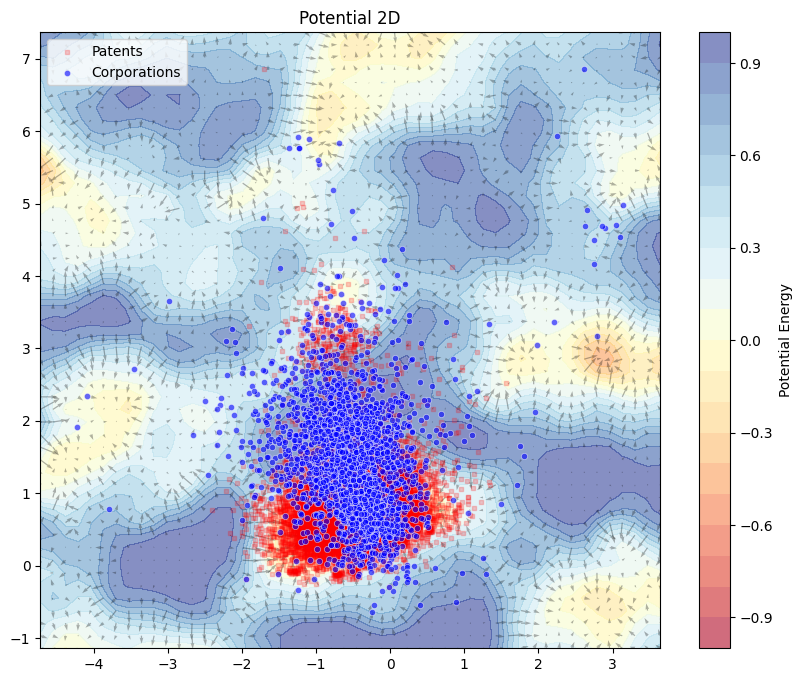

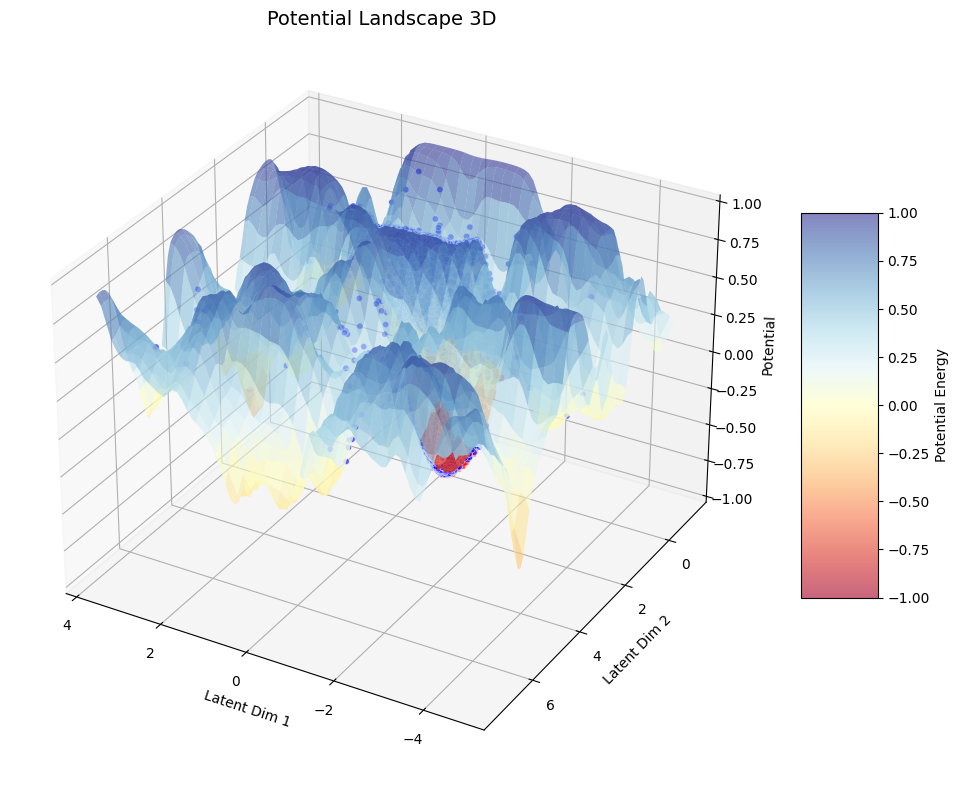

In [1]:
import time
import pandas as pd
import numpy as np
import ast
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from torchdiffeq import odeint_adjoint as odeint
from torch.optim.lr_scheduler import ReduceLROnPlateau
import warnings
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 3Dプロット用

# 基本設定
warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# 1. データ前処理
# ============================================================
def safe_parse_embedding(x):
    """埋め込みベクトルの文字列を安全にパースする"""
    if pd.isna(x) or x == "":
        return None
    if isinstance(x, (list, np.ndarray)):
        return np.array(x, dtype=np.float32)
    if isinstance(x, str):
        try:
            s = re.sub(r'[\[\]\n]', '', x)
            s = s.replace(',', ' ')
            vals = np.array([float(v) for v in s.split() if v], dtype=np.float32)
            return vals if len(vals) > 0 else None
        except Exception:
            return None
    return None

def preprocess_data(file_path):
    print("1. データ読み込み開始...")
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"エラー: ファイル '{file_path}' が見つかりません。")
        return pd.DataFrame()

    print("2. 埋め込みベクトルを結合中...")
    combined_vectors = []
    valid_indices = []
    
    for i, row in df.iterrows():
        desc = safe_parse_embedding(row.get('description_embedding', ''))
        meta = safe_parse_embedding(row.get('metadata_embedding', ''))
        
        if desc is not None and meta is not None:
            if len(desc) > 0 and len(meta) > 0:
                combined_vectors.append(np.concatenate([desc, meta]))
                valid_indices.append(i)
        
        if i % 10000 == 0 and i > 0:
            print(f"  {i}件処理済み...")

    if not combined_vectors:
        print("警告: 有効なベクトルデータがありません。")
        return pd.DataFrame()

    df = df.iloc[valid_indices].copy()
    df['combined_vector'] = combined_vectors
    
    def parse_corp(x):
        try:
            return ast.literal_eval(x) if isinstance(x, str) else x
        except:
            return [x] if isinstance(x, str) else x
    
    if "corporation" in df.columns:
        df["corporation"] = df["corporation"].apply(parse_corp)
        df["corporation"] = df["corporation"].apply(lambda x: x if isinstance(x, list) else [])
    
    if "year_month" in df.columns:
        df['year_month'] = pd.to_datetime(df['year_month'], errors='coerce')
        df = df.dropna(subset=['year_month'])
        df = df[(df['year_month'] >= '2010-01-01') & (df['year_month'] <= '2020-12-31')]
    
    print(f"✓ 前処理完了: {len(df)} 件")
    return df

def calculate_initial_corp_vectors(df, num_corps, input_dim, all_corporations):
    """
    企業の初期ベクトルを「保有特許の平均」で計算する関数
    """
    print("Initializing corporate vectors with patent means...")
    corp_vectors = np.zeros((num_corps, input_dim), dtype=np.float32)
    corp_counts = np.zeros(num_corps, dtype=np.float32)
    
    # Corp名 -> Index のマップ
    corp_to_idx = {c: i for i, c in enumerate(all_corporations)}
    
    for _, row in df.iterrows():
        vec = row['combined_vector']
        if vec is None or len(vec) != input_dim: continue
        
        corps = row['corporation']
        for c in corps:
            if c in corp_to_idx:
                idx = corp_to_idx[c]
                corp_vectors[idx] += vec
                corp_counts[idx] += 1
    
    # 平均化 (特許がない企業はゼロのまま、あるいはランダムノイズを加える)
    for i in range(num_corps):
        if corp_counts[i] > 0:
            corp_vectors[i] /= corp_counts[i]
        else:
            # 特許がない場合は小さなランダム値で初期化
            corp_vectors[i] = np.random.normal(0, 0.01, input_dim)
            
    return torch.tensor(corp_vectors, dtype=torch.float32)

# ============================================================
# 2. モデルコンポーネント定義
# ============================================================

# --- GAT Encoder ---
class SharedVGAEEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels * 2, heads=2, concat=False)
        self.conv2 = GATConv(hidden_channels * 2, hidden_channels, heads=2, concat=False)
        self.conv3 = GATConv(hidden_channels, hidden_channels, heads=1, concat=False)
        self.conv_mu = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.dropout = nn.Dropout(0.2)
        self.batch_norm1 = nn.BatchNorm1d(hidden_channels * 2)
        self.batch_norm2 = nn.BatchNorm1d(hidden_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.batch_norm1(self.conv1(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.batch_norm2(self.conv2(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)

# --- PotentialNet (With Grid Computation) ---
class PotentialNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        # Random Fourier Features (RFF) 用の周波数行列
        self.B = nn.Parameter(torch.randn(latent_dim, hidden_dim // 2) * 3.0, requires_grad=False)

        input_features = hidden_dim # sin/cos projectionにより次元が決定
        
        self.net = nn.Sequential(
            nn.Linear(input_features, hidden_dim * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1),
            nn.Tanh()
        )

    def forward(self, z):
        # 座標 z を高周波空間へ射影
        proj = torch.matmul(z, self.B)
        x = torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)
        return self.net(x)

    def compute_potential_grid(self, x_range, y_range, resolution=50, device='cpu'):
        """グリッド上でポテンシャルを計算"""
        x = torch.linspace(x_range[0], x_range[1], resolution)
        y = torch.linspace(y_range[0], y_range[1], resolution)
        X, Y = torch.meshgrid(x, y, indexing='ij')
        
        # モデル入力用にフラット化
        grid_points = torch.stack([X.flatten(), Y.flatten()], dim=1).to(device)
        
        # ポテンシャル計算
        model_device = next(self.parameters()).device
        with torch.no_grad():
            potentials = self.forward(grid_points.to(model_device))
        
        return (
            X.cpu().numpy(), 
            Y.cpu().numpy(), 
            potentials.view(resolution, resolution).cpu().numpy()
        )

# --- GradientODEFunc (With Gradient Field Computation) ---
class GradientODEFunc(nn.Module):
    def __init__(self, potential_net):
        super().__init__()
        self.potential_net = potential_net
        self.scale = nn.Parameter(torch.tensor(0.1))

    def forward(self, t, z):
        # 勾配フロー: dz/dt = -grad(Phi)
        with torch.set_grad_enabled(True):
            z_in = z.detach().requires_grad_(True)
            phi = self.potential_net(z_in)
            grad_z = torch.autograd.grad(phi.sum(), z_in, create_graph=True)[0]
        
        # tanhで勾配の大きさを制限し、学習を安定化
        return - torch.tanh(self.scale) * grad_z
    
    def compute_gradient_field(self, X, Y, device='cpu'):
        """グリッド上で勾配ベクトル場を計算"""
        grid_points = torch.tensor(
            np.stack([X.flatten(), Y.flatten()], axis=1), 
            dtype=torch.float32, device=device
        )
        grid_points.requires_grad_(True)
        
        phi = self.potential_net(grid_points)
        gradients = torch.autograd.grad(phi.sum(), grid_points, create_graph=False)[0]
        
        # Hamiltonian/Gradient Flowにおける「移動方向」は -gradient
        grad_x = gradients[:, 0].view(X.shape).cpu().numpy()
        grad_y = gradients[:, 1].view(X.shape).cpu().numpy()
        
        return grad_x, grad_y

class GradientNeuralODEPredictor(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.potential_net = PotentialNet(latent_dim, hidden_dim)
        self.ode_func = GradientODEFunc(self.potential_net)

    def forward(self, z_current, delta_t=1.0):
        t_span = torch.tensor([0., delta_t], device=z_current.device)
        # odeintで積分し、最後の時刻の状態を返す
        z_future = odeint(
            self.ode_func, z_current, t_span,
            method='dopri5', rtol=1e-3, atol=1e-3
        )[-1]
        return z_future

# ============================================================
# 3. 統合モデル (UnifiedVGAE)
# ============================================================
class UnifiedVGAE(nn.Module):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=256,
                 latent_dim=2, sequence_length=3, initial_corp_vectors=None):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_corps = num_corps
        self.latent_dim = latent_dim
        
        # 企業用埋め込み設定
        self.corp_embeddings = nn.Embedding(num_corps, input_dim)
        if initial_corp_vectors is not None:
            # 【変更点】計算済みの平均ベクトルで初期化
            self.corp_embeddings.weight.data.copy_(initial_corp_vectors)
        else:
            nn.init.normal_(self.corp_embeddings.weight, mean=0.0, std=0.05)
        
        self.encoder = SharedVGAEEncoder(input_dim, hidden_dim, latent_dim)
        self.temporal_predictor = GradientNeuralODEPredictor(latent_dim, hidden_dim)

        self.link_predictor = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1)
        )

    def get_node_features(self, x, node_indices=None):
        features = x.clone()
        if node_indices is None:
            node_indices = torch.arange(self.num_nodes, device=x.device)
        corp_idx = node_indices[node_indices < self.num_corps]
        if corp_idx.numel() > 0:
            features[corp_idx] = self.corp_embeddings(corp_idx)
        return features

    def encode(self, x, edge_index, node_indices=None):
        x_features = self.get_node_features(x, node_indices)
        mu, logvar = self.encoder(x_features, edge_index)
        z = self.reparameterize(mu, logvar)
        return z, mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar)
        return mu

    def decode(self, z, edge_index):
        z_src = z[edge_index[0]]
        z_dst = z[edge_index[1]]
        # === 変更前 (MLP) ===
        # return torch.sigmoid(self.link_predictor(torch.cat([z_src, z_dst], dim=-1))).squeeze()
        # === 変更後 (内積: Inner Product) ===
        # 内積が大きい(=角度が近くベクトルが長い)ほど確率が高くなる
        return torch.sigmoid((z_src * z_dst).sum(dim=1))
    
    def predict_future(self, z_history_list):
        # 最新の潜在変数からODEで未来へ飛ばす
        return self.temporal_predictor(z_history_list[-1])

# ============================================================
# 4. 損失関数と補助関数
# ============================================================
def sample_hard_negatives_v2(model, z, active_corps, active_patents, 
                             pos_set, historical_edges, num_samples=1000):
    if len(active_corps) == 0 or len(active_patents) == 0:
        return None
    
    neg_edges = []
    # ランダム候補生成
    cand_c = active_corps[torch.randint(0, len(active_corps), (num_samples * 5,))]
    cand_p = active_patents[torch.randint(0, len(active_patents), (num_samples * 5,))]

    # 距離計算 (近いのにリンクがないペアを探す)
    dists = torch.norm(z[cand_c] - z[cand_p], dim=1)
    sorted_indices = torch.argsort(dists)
    
    for idx in sorted_indices:
        c, p = cand_c[idx].item(), cand_p[idx].item()
        edge = (c, p)
        if edge not in pos_set and edge not in historical_edges:
            neg_edges.append([c, p])
            if len(neg_edges) >= num_samples:
                break
                
    if not neg_edges:
        return None
    return torch.tensor(neg_edges, dtype=torch.long, device=z.device).t().contiguous()

def compute_loss_standardized(model, data_t, data_t1, num_corps, z_history_for_prediction,
                              historical_edges, beta=0.01, pos_weight=5.0, 
                              latent_pred_weight=1.0, future_link_weight=10.0,
                              potential_weight=10.0, repulsion_weight=5.0): # potential_weight 5.0 -> 5.0に変更
    device = data_t.x.device
    node_indices = torch.arange(model.num_nodes, device=device)
    patent_mask = (node_indices >= num_corps) & data_t.active_mask
    
    # 1. エンコード
    z_t, mu_t, logvar_t = model.encode(data_t.x, data_t.edge_index)
    
    # 2. 再構成損失
    pos_edge_index = data_t.edge_index
    active_corps = torch.unique(pos_edge_index[0][pos_edge_index[0] < num_corps])
    active_patents = torch.unique(pos_edge_index[1][pos_edge_index[1] >= num_corps])
    pos_set = set(tuple(p.tolist()) for p in pos_edge_index.t())
    
    neg_edge_index = sample_hard_negatives_v2(model, z_t, active_corps, active_patents, 
                                                pos_set, historical_edges, num_samples=500)
    
    recon_loss = torch.tensor(0.0, device=device)
    if neg_edge_index is not None:
        pos_pred = model.decode(z_t, pos_edge_index)
        neg_pred = model.decode(z_t, neg_edge_index)
        # ハブ対策（次数重み付け）
        node_degrees = torch.zeros(model.num_nodes, device=device)
        node_degrees.index_add_(0, data_t.edge_index.view(-1), torch.ones(data_t.edge_index.numel(), device=device))
        edge_rarity = 1.0 / torch.log(node_degrees[pos_edge_index[0]] * node_degrees[pos_edge_index[1]] + 1e-15)
        
        recon_loss = -(torch.log(pos_pred + 1e-15) * edge_rarity).mean() * pos_weight \
                     - torch.log(1 - neg_pred + 1e-15).mean()

    # KL損失
    kl_loss = -0.5 * torch.mean(1 + logvar_t[data_t.active_mask] - mu_t[data_t.active_mask].pow(2) - logvar_t[data_t.active_mask].exp())

    # 3. ポテンシャル学習 (人気の特許＝深い谷)
    potential_loss = torch.tensor(0.0, device=device)
    unique_patents, counts = torch.unique(data_t.edge_index[1], return_counts=True)
    has_potential = hasattr(model.temporal_predictor, 'potential_net')
    
    if potential_weight > 0 and has_potential:
        unique_patents, counts = torch.unique(data_t.edge_index[1], return_counts=True)
        if unique_patents.numel() > 0:
            target_phi = torch.zeros(model.num_nodes, 1, device=device)
            ranks = torch.argsort(torch.argsort(counts.float())).float()
            # 人気があるほど -1.0 (谷)、ないほど 1.0 (山)
            normalized_target = 1.0 - (ranks / (ranks.max() + 1e-9)) * 2.0
            target_phi[unique_patents] = normalized_target.view(-1, 1)
            
            predicted_phi = model.temporal_predictor.potential_net(mu_t)
            potential_loss = F.mse_loss(predicted_phi[patent_mask], target_phi[patent_mask])

    # 4. 未来予測 (ODE)
    z_t1_pred = model.predict_future(z_history_for_prediction)
    with torch.no_grad():
        _, mu_t1_actual, _ = model.encode(data_t1.x, data_t1.edge_index)
    latent_pred_loss = F.mse_loss(z_t1_pred[data_t1.active_mask], mu_t1_actual[data_t1.active_mask])

    # 5. 未来リンク予測
    future_link_loss = torch.tensor(0.0, device=device)
    pos_edge_index_t1 = data_t1.edge_index
    if pos_edge_index_t1.size(1) > 0:
        active_c_t1 = torch.unique(pos_edge_index_t1[0][pos_edge_index_t1[0] < num_corps])
        active_p_t1 = torch.unique(pos_edge_index_t1[1][pos_edge_index_t1[1] >= num_corps])
        pos_set_t1 = set(tuple(p.tolist()) for p in pos_edge_index_t1.t())
        
        neg_t1 = sample_hard_negatives_v2(model, z_t1_pred, active_c_t1, active_p_t1, pos_set_t1, historical_edges, num_samples=300)
        if neg_t1 is not None:
            future_link_loss = -torch.log(model.decode(z_t1_pred, pos_edge_index_t1) + 1e-15).mean() * pos_weight - \
                               torch.log(1 - model.decode(z_t1_pred, neg_t1) + 1e-15).mean()

    # 6. 反発力損失 (特許間が近づきすぎないように)
    repulsion_loss = torch.tensor(0.0, device=device)
    z_patents = z_t[patent_mask]
    if z_patents.size(0) > 100: # 計算負荷軽減のためサンプリングまたは条件付き
        idx_sub = torch.randperm(z_patents.size(0))[:200]
        z_sub = z_patents[idx_sub]
        dist_matrix = torch.cdist(z_sub, z_sub)
        eye_mask = ~torch.eye(dist_matrix.size(0), dtype=torch.bool, device=device)
        repulsion_loss = torch.relu(0.5 - dist_matrix[eye_mask]).mean()

    total_loss = (recon_loss + beta * kl_loss + latent_pred_weight * latent_pred_loss + 
                  future_link_weight * future_link_loss + potential_weight * potential_loss + 
                  repulsion_weight * repulsion_loss)
    
    return total_loss, {
        'total': total_loss.item(), 'potential': potential_loss.item(), 
        'future': future_link_loss.item(), 'repulsion': repulsion_loss.item()
    }

def calculate_evidence_metrics(model, data_t, z_now, z_future):
    """モデルの物理的な妥当性を示す指標を計算"""
    model.eval()
    active_mask = data_t.active_mask
    z_active = z_now[active_mask]
    z_fut_active = z_future[active_mask]
    
    # 1. 空間分散度
    centroid = z_active.mean(dim=0)
    dispersion = torch.mean(torch.sum((z_active - centroid)**2, dim=1)).item()
    
    # 2. 物理的一致度 (Cosine Sim between Actual Move & Gradient)
    v_actual = z_fut_active - z_active
    z_req = z_active.detach().clone().requires_grad_(True)
    with torch.set_grad_enabled(True):
        phi = model.temporal_predictor.potential_net(z_req)
        # Gradient Flow: v = -grad(Phi)
        v_theoretical = -torch.autograd.grad(phi.sum(), z_req)[0]
    
    cos_sim = F.cosine_similarity(v_actual, v_theoretical, dim=1)
    avg_consistency = cos_sim.mean().item()
    
    return {"dispersion": dispersion, "consistency": avg_consistency}

# ============================================================
# 5. 評価関数 (MRR / Hits@K)
# ============================================================
def compute_ranking_metrics(model, z_pred, pos_edge_index, num_corps, all_true_edges):
    model.eval()
    if pos_edge_index.size(1) == 0: return None
    
    # 企業 -> 特許 のエッジのみ抽出
    mask = (pos_edge_index[0] < num_corps) & (pos_edge_index[1] >= num_corps)
    eval_edges = pos_edge_index[:, mask]
    if eval_edges.size(1) == 0: return None
    
    active_patents = torch.unique(pos_edge_index[1][pos_edge_index[1] >= num_corps])
    if len(active_patents) < 2: return None
    
    reciprocal_ranks = []
    hits_at_10 = []
    
    # 高速化のためサンプリング評価
    num_eval = min(eval_edges.size(1), 300)
    indices = torch.randperm(eval_edges.size(1))[:num_eval]
    
    for idx in indices:
        src, dst = eval_edges[0, idx].item(), eval_edges[1, idx].item()
        
        neg_candidates = []
        while len(neg_candidates) < 99:
            neg = active_patents[torch.randint(len(active_patents), (1,))].item()
            if neg != dst and (src, neg) not in all_true_edges:
                neg_candidates.append(neg)
        
        targets = [dst] + neg_candidates
        src_repeated = torch.tensor([src] * len(targets), device=z_pred.device)
        dst_tensor = torch.tensor(targets, device=z_pred.device)
        
        with torch.no_grad():
            scores = model.decode(z_pred, torch.stack([src_repeated, dst_tensor]))
        
        rank = (scores > scores[0]).sum().item() + 1
        reciprocal_ranks.append(1.0 / rank)
        hits_at_10.append(1.0 if rank <= 10 else 0.0)
        
    return {'mrr': np.mean(reciprocal_ranks), 'hits@10': np.mean(hits_at_10)}

# ============================================================
# 6. 学習ループ
# ============================================================
def train_model_improved(model, global_graph_dict, num_corps, historical_edges, num_epochs=20):
    device = next(model.parameters()).device
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    
    years = sorted(global_graph_dict.keys())
    train_years = years[:int(len(years) * 0.75)]
    val_years = years[int(len(years) * 0.75):]
    
    history = {'train_loss': [], 'val_mrr': [], 'dispersion': [], 'consistency': []}
    
    all_true_edges = set()
    for y in years:
        all_true_edges.update([tuple(e) for e in global_graph_dict[y].edge_index.t().tolist()])
    
    best_mrr = 0.0
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        
        # --- Train ---
        for i in range(len(train_years) - 1):
            year_t = train_years[i]
            year_t1 = train_years[i + 1]
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            # 履歴zの構築
            z_history = []
            for j in range(max(0, i - 2), i + 1):
                with torch.no_grad():
                    d = global_graph_dict[train_years[j]].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_history.append(z)
            
            optimizer.zero_grad()
            loss, _ = compute_loss_standardized(model, data_t, data_t1, num_corps, z_history, historical_edges)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            
            # 最終ステップでエビデンス計算
            if i == len(train_years) - 2:
                with torch.no_grad():
                    z_t = z_history[-1]
                    z_pred = model.predict_future(z_history)
                    metrics = calculate_evidence_metrics(model, data_t, z_t, z_pred)
                    history['dispersion'].append(metrics['dispersion'])
                    history['consistency'].append(metrics['consistency'])

        avg_loss = epoch_loss / len(train_years)
        history['train_loss'].append(avg_loss)
        
        # --- Validation ---
        model.eval()
        val_mrr_list = []
        for i in range(len(val_years) - 1):
            year_t = val_years[i]
            year_t1 = val_years[i + 1]
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            # 検証用の履歴構築
            z_hist_val = []
            for y in [py for py in years if py <= year_t][-3:]:
                 with torch.no_grad():
                    d = global_graph_dict[y].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist_val.append(z)
            
            with torch.no_grad():
                z_pred = model.predict_future(z_hist_val)
                res = compute_ranking_metrics(model, z_pred, data_t1.edge_index, num_corps, all_true_edges)
                if res: val_mrr_list.append(res['mrr'])

        val_mrr = np.mean(val_mrr_list) if val_mrr_list else 0.0
        history['val_mrr'].append(val_mrr)
        
        scheduler.step(val_mrr)
        if val_mrr > best_mrr: best_mrr = val_mrr
        
        print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | MRR: {val_mrr:.4f} | "
              f"Consist: {history['consistency'][-1]:.3f}")

    return model, best_mrr, history

# ============================================================
# 7. 可視化関数 (2D & 3D)
# ============================================================
def visualize_potential_landscape_2d(model, data, num_corps, device, title="Potential 2D"):
    """2D Contour Plot + Vector Field"""
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        z, _, _ = model.encode(data.x, data.edge_index)
        z_np = z.cpu().numpy()
        
    x_min, x_max = z_np[:, 0].min(), z_np[:, 0].max()
    y_min, y_max = z_np[:, 1].min(), z_np[:, 1].max()
    margin = 0.5
    
    # グリッド計算
    X, Y, Z = model.temporal_predictor.potential_net.compute_potential_grid(
        (x_min - margin, x_max + margin), 
        (y_min - margin, y_max + margin), 
        resolution=50, device=device
    )
    
    # 勾配場計算
    grad_x, grad_y = model.temporal_predictor.ode_func.compute_gradient_field(X, Y, device=device)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    levels = np.linspace(-1.0, 1.0, 21)
    contour = ax.contourf(X, Y, Z, levels=20, cmap='RdYlBu', alpha=0.6)
    plt.colorbar(contour, label='Potential Energy')
    
    # ベクトル場 (-gradient = movement direction)
    ax.quiver(X, Y, -grad_x, -grad_y, color='black', alpha=0.3, width=0.002)
    
    # Scatter
    z_c = z_np[:num_corps]
    z_p = z_np[num_corps:]
    ax.scatter(z_p[:, 0], z_p[:, 1], c='red', marker='s', s=10, alpha=0.2, label='Patents')
    ax.scatter(z_c[:, 0], z_c[:, 1], c='blue', marker='o',s=20, edgecolors='white', linewidth = 0.5, alpha=0.6, label='Corporations')
    
    ax.set_title(title)
    ax.legend()
    plt.show()

def visualize_potential_landscape_3d(model, data, num_corps, device, title="Potential Landscape 3D"):
    """
    3D Surface Plot
    ポテンシャル地形を立体的に表示し、ノードの配置を確認する
    """
    
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        z, _, _ = model.encode(data.x, data.edge_index)
        z_np = z.cpu().numpy()

    # 範囲設定
    x_min, x_max = z_np[:, 0].min(), z_np[:, 0].max()
    y_min, y_max = z_np[:, 1].min(), z_np[:, 1].max()
    margin = 0.5
    
    # 高解像度グリッド
    X, Y, Z = model.temporal_predictor.potential_net.compute_potential_grid(
        (x_min - margin, x_max + margin), 
        (y_min - margin, y_max + margin), 
        resolution=80, device=device
    )

    # 2. 勾配(ベクトル)の計算 【追加箇所】
    # 2Dと同様に勾配場を計算します
    grad_x, grad_y = model.temporal_predictor.ode_func.compute_gradient_field(X, Y, device=device)
    
    # ODEのダイナミクスは -grad (坂を下る方向) なので符号反転
    U = -grad_x
    V = -grad_y
    # Z方向の矢印成分は0にします（「平面上の移動方向」を示したいため水平に描画）
    W = np.zeros_like(U) 

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # 1. 地形のプロット (Surface)
    # cmap='viridis' や 'RdYlBu_r' (逆転) を使用して、低い場所(谷)を見やすくする
    surf = ax.plot_surface(X, Y, Z, cmap='RdYlBu', vmin=-1.0, vmax=1.0,edgecolor='none', alpha=0.6)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Potential Energy')

    # 2. ノードのプロット (Scatter 3D)
    # ノードの高さ(Z座標)は、その位置でのポテンシャル値にする
    with torch.no_grad():
        potentials_nodes = model.temporal_predictor.potential_net(z).cpu().numpy().flatten()
    
    # 特許 (黒/グレー)
    z_p = z_np[num_corps:]
    pot_p = potentials_nodes[num_corps:]
    # 数が多い場合はサンプリングして表示
    if len(z_p) > 500:
        idx = np.random.choice(len(z_p), 500, replace=False)
        z_p = z_p[idx]
        pot_p = pot_p[idx]
        
    ax.scatter(z_p[:, 0], z_p[:, 1], pot_p, c='red', marker='s', s=10, alpha=0.2, label='Patents')

    # 企業 (赤)
    z_c = z_np[:num_corps]
    pot_c = potentials_nodes[:num_corps]
    ax.scatter(z_c[:, 0], z_c[:, 1], pot_c, c='blue', marker='o', s=20, edgecolors='white', linewidth = 0.5, alpha=0.6, label='Corporations')

    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Latent Dim 1')
    ax.set_ylabel('Latent Dim 2')
    ax.set_zlabel('Potential')
    
    # Z軸の範囲を設定
    ax.set_zlim(-1.0, 1.0)
    # 視点の調整 (必要に応じて変更)
    ax.view_init(elev=30, azim=120)
    plt.show()

def build_global_graphs(df):
    """グラフ構築関数（以前のバージョンと同じ）"""
    all_corporations = sorted(list(set([c for corps in df['corporation'] for c in corps])))
    all_patents = sorted(df['patent_number'].unique().tolist())
    
    corp_to_idx = {corp: i for i, corp in enumerate(all_corporations)}
    patent_to_idx = {patent: i + len(all_corporations) for i, patent in enumerate(all_patents)}
    total_nodes = len(all_corporations) + len(all_patents)
    
    patent_features = {}
    for _, row in df.iterrows():
        patent_features[row['patent_number']] = row['combined_vector']
    
    input_dim = len(next(iter(patent_features.values()))) if patent_features else 10

    global_graph_dict = {}
    year_groups = df.groupby(df['year_month'].dt.year)
    all_historical_edges = set()
    
    for year, group in year_groups:
        edges = []
        for _, row in group.iterrows():
            if row['patent_number'] not in patent_to_idx: continue
            p_idx = patent_to_idx[row['patent_number']]
            for corp in row['corporation']:
                if corp in corp_to_idx:
                    c_idx = corp_to_idx[corp]
                    edges.append([c_idx, p_idx]) # Corp -> Patent
                    edges.append([p_idx, c_idx]) # Patent -> Corp
                    all_historical_edges.add((c_idx, p_idx))
        
        if not edges: continue
        
        x = torch.zeros(total_nodes, input_dim)
        for p_num, p_idx in patent_to_idx.items():
            if p_num in patent_features: x[p_idx] = torch.tensor(patent_features[p_num])
        
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        active_mask = torch.zeros(total_nodes, dtype=torch.bool)
        active_mask[torch.unique(edge_index)] = True
        
        global_graph_dict[year] = Data(x=x, edge_index=edge_index, active_mask=active_mask, num_nodes=total_nodes)
        
    return global_graph_dict, all_corporations, all_patents, total_nodes, all_historical_edges, input_dim

# ============================================================
# Main Execution
# ============================================================
if __name__ == "__main__":
    print("=" * 60)
    print("Hamiltonian-ODE Dynamic Graph Learning (3D Visualization Ready)")
    print("=" * 60)
    
    # 1. データ準備
    df = preprocess_data('../dataset/topic_info3.csv')
    if len(df) == 0: exit()
    
    # 2. グラフ構築
    graphs, corps, patents, total_n, hist_edges, in_dim = build_global_graphs(df)
    num_corps = len(corps)
    print(f"Nodes: {total_n}, Corps: {num_corps}, Dim: {in_dim}")

    # 【追加】初期ベクトルの計算
    init_vectors = calculate_initial_corp_vectors(df, num_corps, in_dim, corps)

    # 3. モデル初期化
    model = UnifiedVGAE(
        num_nodes=total_n, num_corps=num_corps, input_dim=in_dim,
        hidden_dim=128, latent_dim=2, 
        initial_corp_vectors=init_vectors
    ).to(device)

    # 4. 学習
    print("\n>>> Training Started...")
    model, best_mrr, history = train_model_improved(
        model, graphs, num_corps, hist_edges, num_epochs=15
    )
    
    print(f"\nTraining Completed. Best MRR: {best_mrr:.4f}")
    
    # 5. 可視化
    last_year = max(graphs.keys())
    print(f"\n[Visualization] Year: {last_year}")
    
    # 2D Plot
    visualize_potential_landscape_2d(model, graphs[last_year], num_corps, device)
    
    # 3D Plot (New!)
    visualize_potential_landscape_3d(model, graphs[last_year], num_corps, device)

In [2]:
df

,patent_number,patent_name,date,corporation,ipc,lead_ipc,fi,fterm,keyword,description,year,month,description_embedding,metadata_embedding,lead_inventor,inventors,year_month,topic_id,sim_score,combined_vector
23373,特開2011-147544,患者搬送装置,201001,[株式会社テクネット],[],A61G 5/00 (2006.01),[],[],"['簡単', '運搬']",場所を取らない簡単な構造により、感染患者等を隔離した状態で搬送することができる,2010,1,"[0.022907990962266922, 0.017237883061170578, -...",[ 0.34335172 -0.19837284 0.26558578 0.187770...,山口 一,"山口 一,伊澤 康一,梶間 智明,田中 勲,辻 裕次,三浦 靖弘,釜石 裕光",2010-01-01,1,0.898545,"[0.022907991, 0.017237883, -0.01705683, -0.029..."
23374,特開2011-147869,二酸化炭素の地中貯留施設およびその施工方法,201001,[清水建設株式会社],"['B01J 19/00 (2006.01)', 'E02D 29/045 (...",B01J 19/00 (2006.01),"['B01J 19/00 A', 'E02D 29/04 A', 'E0...","['2D047AB02', '4G075AA04', '2D147AB02']","['二酸化炭素', '貯留', '有効適切', '施工方法']",二酸化炭素の非構造型貯留層への貯留を可能とする有効適切な地中貯留施設とその施工方法を提供する,2010,1,"[0.030319971963763237, -0.015537390485405922, ...",[ 0.25184226 -0.23450097 0.24443543 0.197358...,米山 一幸,米山 一幸,2010-01-01,8,0.913877,"[0.030319972, -0.0155373905, -0.01071435, -0.0..."
23375,特開2011-149178,導枠及び海底探査方法,201001,"[株式会社熊谷組, 東光電気工事株式会社, 株式会社森長組]","['E02D 13/04 (2006.01)', 'E02D 27/52 (...",E02D 13/04 (2006.01),['E02D 13/04'],"['2D046DA62', '2D050AA06', '2D050CB14', '2D050...","['短期化', '施工コスト', '低減化']",工期の短縮化や施工コストの低減化を図る,2010,1,"[0.006442359182983637, 0.020957233384251595, -...",[ 3.8005432e-01 -2.2637601e-01 1.2717944e-01 ...,牛腸 明,"牛腸 明,矢嶋 英明,竹村 雅彦,岡野 雅史,島田 喜章,谷口 岩男",2010-01-01,5,0.926848,"[0.006442359, 0.020957233, -0.01782004, -0.052..."
23376,特開2011-149181,モノパイル式基礎施工方法,201001,"[株式会社熊谷組, 東光電気工事株式会社]","['E02D 7/00 (2006.01)', 'E02D 27/32 (...",E02D 7/00 (2006.01),"['E02D 7/00 A', 'E02D 27/32 A', 'E0...","['2D046CA08', '2D046DA05', '2D050AA01', '2D050...","['短期化', '施工コスト', '低減化']",工期の短縮化や施工コストの低減化を図る,2010,1,"[0.006442359182983637, 0.020957233384251595, -...",[ 0.37698632 -0.23764831 0.13028508 0.141271...,牛腸 明,"牛腸 明,矢嶋 英明,竹村 雅彦,岡野 雅史",2010-01-01,5,0.926848,"[0.006442359, 0.020957233, -0.01782004, -0.052..."
23377,特開2011-149182,杭基礎の施工方法,201001,[株式会社熊谷組],"['E02D 27/12 (2006.01)', 'E02D 27/16 (...",E02D 27/12 (2006.01),"['E02D 27/12 Z', 'E02D 27/16']","['2D046CA01', '2D046CA08']","['グラウト', '短期化', '施工コスト', '低減化']",グラウトの漏出を確実に防止すると共に、工期の短縮化や施工コストの低減化を図る,2010,1,"[-0.005412539932876825, 0.014347787015140057, ...",[ 0.3640074 -0.2338481 0.13964486 0.139466...,牛腸 明,"牛腸 明,矢嶋 英明",2010-01-01,3,0.933085,"[-0.00541254, 0.014347787, -0.023784904, -0.04..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42757,WO2021/140940,農産物栽培支援装置、農産物栽培システム、および農産物栽培支援方法,202012,"[株式会社大林組, 原嶋 寛, 住吉 栄作, 緒方 浩基]","['G06Q 50/02 (2012.01)', 'A01G 7/00 (...",G06Q 50/02 (2012.01),[],[],['測定値'],農産物栽培支援装置は、農業ハウスの栽培空間の複数の光合成要素について測定値を取得する,2020,12,"[0.0313706174492836, 0.01707536354660988, -0.0...",[ 0.19453254 -0.30019754 0.10449462 0.146774...,原嶋 寛,"原嶋 寛,住吉 栄作,緒方 浩基",2020-12-01,2,0.881575,"[0.031370617, 0.017075364, -0.03717448, -0.047..."
42758,WO2021/140941,収穫予測装置、収穫予測方法,202012,"[株式会社大林組, 中村 奈美]","['G06Q 50/02 (2012.01)', 'A01G 7/00 (...",G06Q 50/02 (2012.01),[],[],[],収穫予測装置は撮像部に接続された制御部を備える,2020,12,"[0.01752316951751709, 0.00962613895535469, -0....",[ 0.24668053 -0.2343066 0.18544462 0.098285...,中村 奈美,中村 奈美,2020-12-01,1,0.883478,"[0.01752317, 0.009626139, -0.019505411, -0.046..."
42759,特開2021-047923,情報処理システム及び情報処理システム用プログラム,202012,[高砂熱学工業株式会社],['G06Q 50/08 (2012.01)'],G06Q 50/08 (2012.01),['G06Q 50/08'],['5L049CC07'],"['建築現場', 'メンテナンス']",建築現場における管理を容易にする,2020,12,"[0.016471637412905693, 0.013141311705112457, -...",[ 0.27461112 -0.21962798 0.1781581 0.259755...,佐藤 彰洋,"佐藤 彰洋,鈴木 崇浩",2020-12-01,1,0.919058,"[0.016471637, 0.013141312, -0.039926685, -0.04..."
42760,特開2021-105333,天井点検口,202012,[前田建設工業株式会社],['E04F 19/08 (2006.01)'],E04F 19/08 (2006.01),[],[],"['軽微', '保守作業']",軽微な保守作業の実施時における操作性を向上させることができる天井点検口を提供する,2020,12,"[0.009724111296236515, 0.008886716328561306, -...",[ 0.26950538 -0.28889984 0.13830602 0.275950...,佐竹 晃,佐竹 晃,2020-12-01,5,0.920917,"[0.009724111, 0.008886716, -0

Running HDBSCAN with c-TF-IDF Keyword Extraction...
  - Clusters found: 1835
  - Calculating c-TF-IDF scores...


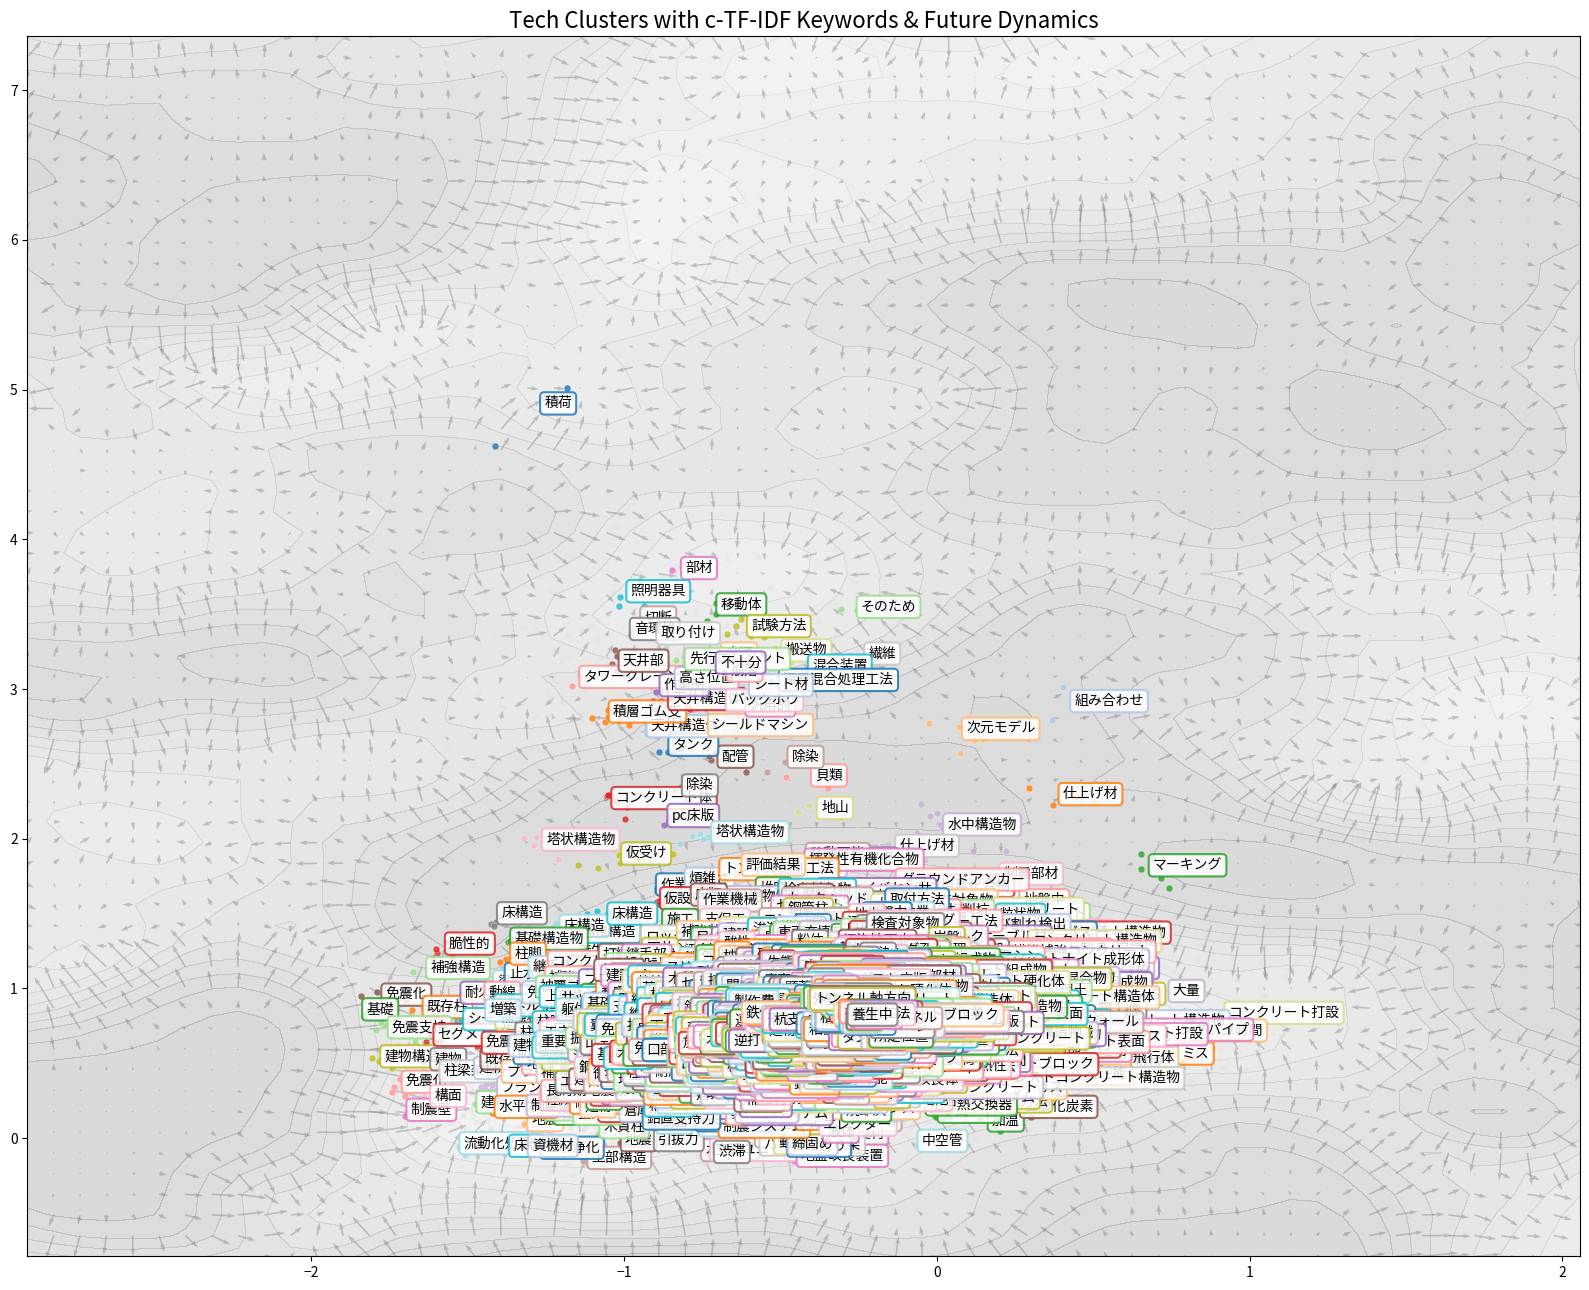

In [31]:
import hdbscan
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import ast
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

# --- ストップワード (一般的な特許用語を除去) ---
PATENT_STOP_WORDS = [
    '方法', '装置', 'システム', '手段', '前記', '特徴', '提供', '本発明', 
    'こと', 'ため', 'よう', '部', 'もの', '等', '構成', '備える', '含む', 
    '配置', '形成', '使用', '利用', '可能', '機能', '構造', '処理', '工程',
    '図', '実施', '形態', '発明', '関係', '状態', '部分', '対応', 'データ',
    '制御', '以上', '以下', '有する', '係る', 'における', 'よる', '行う',
    'おいて', '及び', '並びに', 'または', 'もしくは', 'その', 'この', 'これら',
    '開示', '記載', '適用', '目的', '効果', '実現', '容易', '向上', '防止','本願発明',
    '従来技術','問題','従来','既存建物'
]

def extract_ctfidf_keywords(docs_per_class, top_n=1):
    """
    c-TF-IDF (Class-based TF-IDF) を計算してトップキーワードを抽出する
    """
    # 1. CountVectorizerで頻度行列を作成
    count = CountVectorizer(token_pattern=r'(?u)\b\w+\b', stop_words=PATENT_STOP_WORDS)
    X = count.fit_transform(docs_per_class['text'])
    words = count.get_feature_names_out()
    
    # 2. c-TF-IDF 計算
    # TF: クラス内の単語頻度 / クラス内の総単語数 (L1正規化に近い)
    # IDF: ログ(総クラス数 / その単語を含むクラス数)
    
    # クラスごとの単語総数
    class_totals = np.array(X.sum(axis=1)).flatten()
    # ゼロ除算回避
    class_totals[class_totals == 0] = 1
    tf = X.toarray() / class_totals[:, None]
    
    # IDF計算
    num_classes = X.shape[0]
    # その単語を含んでいるクラスの数
    docs_with_word = (X > 0).sum(axis=0).flatten()
    idf = np.log((num_classes + 1) / (docs_with_word + 1)) + 1
    
    # c-TF-IDF スコア行列
    c_tfidf = np.asarray(tf) * np.asarray(idf)
    
    # 3. トップワード抽出
    labels = docs_per_class['label'].values
    cluster_keywords = {}
    
    for i, label in enumerate(labels):
        # スコアが高い順にソート
        indices = c_tfidf[i].argsort()[::-1]
        top_words = []
        for idx in indices[:top_n]:
            top_words.append(words[idx])
        cluster_keywords[label] = " ".join(top_words)
        
    return cluster_keywords

def visualize_hdbscan_ctfidf(model, data, df, num_corps, device, 
                             min_cluster_size=3, min_samples=None):
    print("Running HDBSCAN with c-TF-IDF Keyword Extraction...")
    
    # 1. 潜在ベクトル取得
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        z, _, _ = model.encode(data.x, data.edge_index)
        z_np = z.cpu().numpy()
        
    z_patents = z_np[num_corps:] # 特許のみ
    
    # 2. HDBSCAN クラスタリング
    clusterer = hdbscan.HDBSCAN(
    min_cluster_size=min_cluster_size, 
    min_samples=min_samples,
    cluster_selection_method='leaf' 
    )
    cluster_labels = clusterer.fit_predict(z_patents)
    
    unique_labels = set(cluster_labels)
    if -1 in unique_labels: unique_labels.remove(-1)
    print(f"  - Clusters found: {len(unique_labels)}")
    
    # 3. テキストデータの準備 (特許番号順に整列)
    all_patents = sorted(df['patent_number'].unique().tolist())
    patent_to_idx = {p: i for i, p in enumerate(all_patents)}
    
    # データフレームにクラスタラベルを付与するためのリスト
    # z_patentsの並び順（sorted patent_number）とdfの行を合わせる必要がある
    
    # patent_number をキーにしてキーワード辞書作成
    p_kw_map = {}
    for _, row in df.iterrows():
        try:
            kws = ast.literal_eval(row['keyword']) if isinstance(row['keyword'], str) else row['keyword']
            if isinstance(kws, list): p_kw_map[row['patent_number']] = " ".join(kws)
        except: continue
            
    # クラスタごとのテキスト統合
    cluster_docs = []
    valid_clusters = []
    
    # クラスタごとにテキストをまとめる
    df_labels = pd.DataFrame({'label': cluster_labels, 'idx': range(len(cluster_labels))})
    
    docs_data = []
    for label in unique_labels:
        # そのクラスタに属する特許のインデックス
        indices = df_labels[df_labels['label'] == label]['idx'].values
        
        texts = []
        for idx in indices:
            if idx < len(all_patents):
                p_num = all_patents[idx]
                if p_num in p_kw_map:
                    texts.append(p_kw_map[p_num])
        
        if len(texts) > 0:
            docs_data.append({'label': label, 'text': " ".join(texts)})
    
    docs_df = pd.DataFrame(docs_data)
    
    # 4. c-TF-IDF でキーワード抽出
    cluster_keywords = {}
    if not docs_df.empty:
        print("  - Calculating c-TF-IDF scores...")
        cluster_keywords = extract_ctfidf_keywords(docs_df, top_n=1)
    
    # 5. プロット準備 (ポテンシャル & ベクトル)
    x_min, x_max = z_patents[:, 0].min(), z_patents[:, 0].max()
    y_min, y_max = z_patents[:, 1].min(), z_patents[:, 1].max()
    margin = 0.5
    X, Y, Z = model.temporal_predictor.potential_net.compute_potential_grid(
        (x_min - margin, x_max + margin), (y_min - margin, y_max + margin), 
        resolution=60, device=device
    )
    grad_x, grad_y = model.temporal_predictor.ode_func.compute_gradient_field(X, Y, device=device)

    # 6. 描画
    fig, ax = plt.subplots(figsize=(16, 13))
    font_prop = set_japanese_font()

    # 背景: ポテンシャル
    contour = ax.contourf(X, Y, Z, levels=20, cmap='Greys', alpha=0.15) # 薄く
    # 背景: ベクトル
    ax.quiver(X, Y, -grad_x, -grad_y, color='#555555', alpha=0.3, width=0.001)
    
    # 色の準備 (tab20など識別しやすい色)
    cmap = plt.get_cmap('tab20')
    colors = [cmap(i % 20) for i in range(len(unique_labels))]
    
    # ノイズ (-1) プロット
    noise_mask = (cluster_labels == -1)
    ax.scatter(z_patents[noise_mask, 0], z_patents[noise_mask, 1], c='#e0e0e0', s=10, alpha=0.3, label='Noise')
    
    # クラスタ プロット
    for label, color in zip(unique_labels, colors):
        mask = (cluster_labels == label)
        points = z_patents[mask]
        
        # 点をプロット
        ax.scatter(points[:, 0], points[:, 1], color=color, s=25, alpha=0.8, edgecolors='white', linewidth=0.3)
        
        # ラベル表示 (c-TF-IDFによる代表語)
        if label in cluster_keywords:
            word = cluster_keywords[label]
            centroid = points.mean(axis=0)
            
            # 白背景のボックス付きテキスト
            ax.text(centroid[0], centroid[1], word, 
                    fontsize=10, color='black', weight='bold', fontproperties=font_prop,
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.85, lw=1.5))

    ax.set_title("Tech Clusters with c-TF-IDF Keywords & Future Dynamics", fontsize=16)
    plt.tight_layout()
    plt.show()

# === 実行 ===
if 'graphs' in locals() and 'model' in locals():
    last_year = max(graphs.keys())
    visualize_hdbscan_ctfidf(
        model, graphs[last_year], df, num_corps, device, 
        min_cluster_size=3 # クラスタサイズ調整
    )

Running HDBSCAN with Unique Labels...
  - Calculating Unique c-TF-IDF labels...


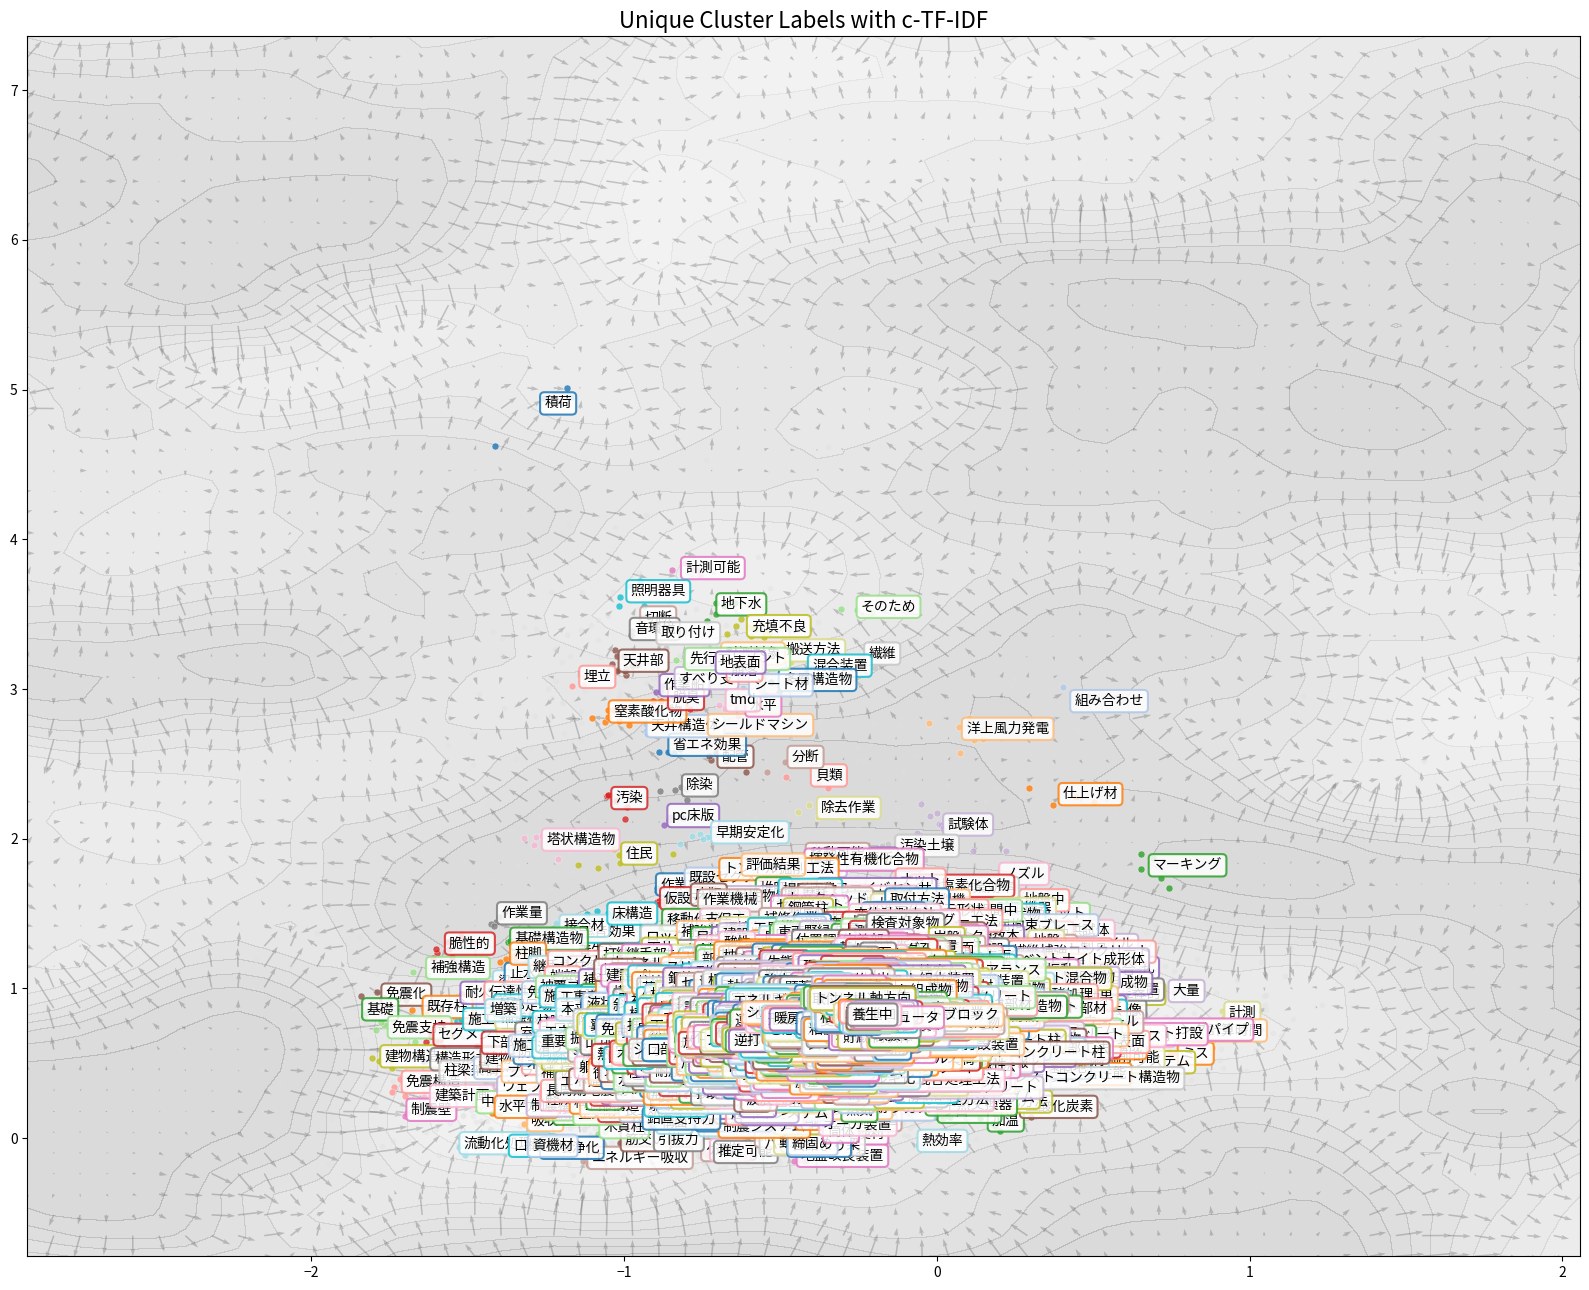

In [32]:
def extract_ctfidf_keywords_unique(docs_per_class, top_n_candidates=10):
    """
    c-TF-IDF を計算し、クラスタ間でラベルが重複しないように割り当てる関数
    """
    # 1. CountVectorizer設定 (あまりに一般的すぎる単語は max_df で弾く)
    count = CountVectorizer(
        token_pattern=r'(?u)\b\w+\b', 
        stop_words=PATENT_STOP_WORDS,
        min_df=2,    # 少なくとも2件の特許に出てくる単語
        max_df=0.9   # 9割の特許に出てくる単語は無視
    )
    
    # テキストがない場合のガード
    if docs_per_class.empty:
        return {}
        
    X = count.fit_transform(docs_per_class['text'])
    words = count.get_feature_names_out()
    
    # 2. c-TF-IDF 計算 (前回修正した安全な計算方法)
    class_totals = np.asarray(X.sum(axis=1)).flatten()
    class_totals[class_totals == 0] = 1
    tf = X.toarray() / class_totals[:, None]
    
    num_classes = X.shape[0]
    docs_with_word = np.asarray((X > 0).sum(axis=0)).flatten()
    idf = np.log((num_classes + 1) / (docs_with_word + 1)) + 1
    c_tfidf = np.asarray(tf) * np.asarray(idf)
    
    # 3. 重複なしラベル割り当てロジック
    
    labels = docs_per_class['label'].values
    cluster_keywords = {}
    used_keywords = set()
    
    # 「クラスタの最大スコア」が高い順に処理する
    # (特徴がはっきりしているクラスタから優先的に良いラベルを与えるため)
    max_scores = c_tfidf.max(axis=1)
    sorted_cluster_indices = max_scores.argsort()[::-1] # 降順ソート
    
    for i in sorted_cluster_indices:
        label_id = labels[i]
        
        # スコアが高い順に単語インデックスを取得
        word_indices = c_tfidf[i].argsort()[::-1]
        
        assigned_word = None
        
        # 上位候補を走査
        for idx in word_indices[:top_n_candidates]:
            candidate = words[idx]
            
            # まだ使われていない単語なら採用
            if candidate not in used_keywords:
                assigned_word = candidate
                used_keywords.add(candidate)
                break
        
        # もし上位候補がすべて使われていた場合 (フォールバック)
        # 上位2単語を結合してユニークにする (例: "制御_モータ")
        if assigned_word is None:
            w1 = words[word_indices[0]]
            w2 = words[word_indices[1]]
            assigned_word = f"{w1}\n{w2}" # 改行を入れて表示
            # 複合語はそのまま登録 (usedチェックはしないが、複合語が被る確率はほぼゼロ)
        
        cluster_keywords[label_id] = assigned_word
        
    return cluster_keywords

# ------------------------------------------------------------------
# 可視化関数の呼び出し部分の変更
# ------------------------------------------------------------------
def visualize_hdbscan_ctfidf_unique(model, data, df, num_corps, device, 
                                    min_cluster_size=10):
    # (前半部分は visualize_hdbscan_ctfidf と同じなので省略可。変更点のみ記載)
    # ...
    # ... (HDBSCAN実行や docs_df 作成までは同じ) ...
    
    # 変更点: 新しい関数を呼び出す
    cluster_keywords = {}
    # docs_df の作成処理などは visualize_hdbscan_ctfidf と同じロジックが必要
    # ここでは既存の関数の該当部分を書き換えることを想定しています
    
    # ↓↓↓ 以下、visualize_hdbscan_ctfidf 関数全体を再掲します ↓↓↓
    print("Running HDBSCAN with Unique Labels...")
    
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        z, _, _ = model.encode(data.x, data.edge_index)
        z_np = z.cpu().numpy()
    z_patents = z_np[num_corps:]

    # HDBSCAN (leafメソッド推奨)
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, cluster_selection_method='leaf')
    cluster_labels = clusterer.fit_predict(z_patents)
    unique_labels = set(cluster_labels)
    if -1 in unique_labels: unique_labels.remove(-1)
    
    # テキスト準備
    all_patents = sorted(df['patent_number'].unique().tolist())
    p_kw_map = {}
    for _, row in df.iterrows():
        try:
            kws = ast.literal_eval(row['keyword']) if isinstance(row['keyword'], str) else row['keyword']
            if isinstance(kws, list): p_kw_map[row['patent_number']] = " ".join(kws)
        except: continue
    
    docs_data = []
    df_labels = pd.DataFrame({'label': cluster_labels, 'idx': range(len(cluster_labels))})
    for label in unique_labels:
        indices = df_labels[df_labels['label'] == label]['idx'].values
        texts = [p_kw_map[all_patents[idx]] for idx in indices if idx < len(all_patents) and all_patents[idx] in p_kw_map]
        if texts: docs_data.append({'label': label, 'text': " ".join(texts)})
    
    docs_df = pd.DataFrame(docs_data)
    
    # ★ ここで新しい関数を使用 ★
    if not docs_df.empty:
        print("  - Calculating Unique c-TF-IDF labels...")
        cluster_keywords = extract_ctfidf_keywords_unique(docs_df)

    # 描画 (ポテンシャル背景などは同じ)
    x_min, x_max = z_patents[:, 0].min(), z_patents[:, 0].max()
    y_min, y_max = z_patents[:, 1].min(), z_patents[:, 1].max()
    margin = 0.5
    X, Y, Z = model.temporal_predictor.potential_net.compute_potential_grid(
        (x_min-margin, x_max+margin), (y_min-margin, y_max+margin), resolution=60, device=device)
    grad_x, grad_y = model.temporal_predictor.ode_func.compute_gradient_field(X, Y, device=device)

    fig, ax = plt.subplots(figsize=(16, 13))
    font_prop = set_japanese_font()
    ax.contourf(X, Y, Z, levels=20, cmap='Greys', alpha=0.15)
    ax.quiver(X, Y, -grad_x, -grad_y, color='#555555', alpha=0.3, width=0.001)
    
    cmap = plt.get_cmap('tab20') # 色数が足りない場合は 'jet' などに変更
    colors = [cmap(i % 20) for i in range(len(unique_labels))]
    
    noise_mask = (cluster_labels == -1)
    ax.scatter(z_patents[noise_mask, 0], z_patents[noise_mask, 1], c='#e0e0e0', s=10, alpha=0.3)
    
    for label, color in zip(unique_labels, colors):
        mask = (cluster_labels == label)
        points = z_patents[mask]
        ax.scatter(points[:, 0], points[:, 1], color=color, s=25, alpha=0.8, edgecolors='white', linewidth=0.3)
        
        if label in cluster_keywords:
            word = cluster_keywords[label]
            centroid = points.mean(axis=0)
            ax.text(centroid[0], centroid[1], word, fontsize=10, color='black', weight='bold', 
                    fontproperties=font_prop,
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.85, lw=1.5))
    
    ax.set_title("Unique Cluster Labels with c-TF-IDF", fontsize=16)
    plt.tight_layout()
    plt.show()

# === 実行 ===
if 'graphs' in locals() and 'model' in locals():
    last_year = max(graphs.keys())
    visualize_hdbscan_ctfidf_unique(
        model, graphs[last_year], df, num_corps, device, 
        min_cluster_size=3 
    )

In [37]:
import torch
import torch.nn.functional as F
import numpy as np
import time
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# ==================================================================================
# 1. 評価用コア関数 (4つの指標を計算)
# ==================================================================================
def evaluate_rq_metrics(model, graphs, num_corps, device):
    """
    学習済みモデルを受け取り、RQ1, RQ2に対応する4つの指標を計算して返す
    対象: テストデータ（時系列の最後の1ステップ）
    """
    model.eval()
    
    # --- データ準備: テスト用期間 (ラスト2年) ---
    years = sorted(graphs.keys())
    target_year = years[-1]       # T+1 (予測対象)
    input_year = years[-2]        # T   (入力)
    history_years = years[-4:-1]  # T-2, T-1, T (履歴系列)
    
    data_target = graphs[target_year].to(device)
    data_input = graphs[input_year].to(device)
    
    # 1. 履歴のエンコード (z_history)
    z_history = []
    with torch.no_grad():
        for y in history_years:
            d = graphs[y].to(device)
            z, _, _ = model.encode(d.x, d.edge_index)
            z_history.append(z)
        
        # 正解の未来座標 (Ground Truth)
        z_true, _, _ = model.encode(data_target.x, data_target.edge_index)
        
        # 予測された未来座標 (Prediction)
        z_pred = model.predict_future(z_history)

    # -------------------------------------------------------
    # RQ1: どこへ動くか？ (Trajectory MSE)
    # -------------------------------------------------------
    # 企業ノードのみ抽出して比較
    mask_corp = torch.arange(model.num_nodes, device=device) < num_corps
    mse_score = F.mse_loss(z_pred[mask_corp], z_true[mask_corp]).item()

    # -------------------------------------------------------
    # RQ1: 誰と繋がるか？ (Link Prediction MRR / Hits@10)
    # -------------------------------------------------------
    # 簡易評価: ランダムな負例99個 vs 正例1個 のランキング
    pos_edges = data_target.edge_index
    # 企業->特許のエッジのみに絞る
    mask_edges = (pos_edges[0] < num_corps) & (pos_edges[1] >= num_corps)
    eval_edges = pos_edges[:, mask_edges]
    
    ranks = []
    hits10 = 0
    num_samples = min(200, eval_edges.size(1)) # 時間短縮のためサンプリング
    
    # 評価用アクティブ特許リスト
    active_patents = torch.unique(pos_edges[1][pos_edges[1] >= num_corps])
    
    with torch.no_grad():
        if len(active_patents) > 100:
            indices = torch.randperm(eval_edges.size(1))[:num_samples]
            for idx in indices:
                src, dst = eval_edges[0, idx].item(), eval_edges[1, idx].item()
                
                # 負例サンプリング
                neg_candidates = active_patents[torch.randint(len(active_patents), (100,))].tolist()
                candidates = [dst] + [n for n in neg_candidates if n != dst][:99]
                
                # スコア計算
                src_repeated = torch.tensor([src] * len(candidates), device=device)
                dst_tensor = torch.tensor(candidates, device=device)
                scores = model.decode(z_pred, torch.stack([src_repeated, dst_tensor]))
                
                # ランク計算 (高い方が良いので降順)
                # 正例(scores[0])より高いスコアを持つ負例の数 + 1
                rank = (scores > scores[0]).sum().item() + 1
                ranks.append(1.0 / rank)
                if rank <= 10: hits10 += 1
                
    mrr_score = np.mean(ranks) if ranks else 0.0
    hits10_score = hits10 / num_samples if num_samples > 0 else 0.0

    # -------------------------------------------------------
    # RQ2: なぜ動くか？ (Consistency)
    # -------------------------------------------------------
    consistency_score = 0.0
    # PotentialNetを持っているモデルのみ計算
    if hasattr(model, 'use_potential') and model.use_potential and hasattr(model.temporal_predictor, 'potential_net'):
        # 直近の移動ベクトル
        z_current = z_history[-1]
        v_actual = z_pred - z_current
        
        # 理論上の勾配 (Force)
        z_req = z_current.detach().clone().requires_grad_(True)
        with torch.set_grad_enabled(True):
            phi = model.temporal_predictor.potential_net(z_req)
            grads = torch.autograd.grad(phi.sum(), z_req, create_graph=False)[0]
            v_theoretical = -grads # 勾配を下る方向
        
        # コサイン類似度 (企業のみ)
        cos_sim = F.cosine_similarity(v_actual[mask_corp], v_theoretical[mask_corp], dim=1)
        consistency_score = cos_sim.mean().item()

    # -------------------------------------------------------
    # RQ2: 構造は綺麗か？ (Silhouette Score)
    # -------------------------------------------------------
    silhouette = 0.0
    try:
        z_cpu = z_pred[mask_corp].cpu().numpy()
        # K-Meansでクラスタリングして凝集度を測る
        kmeans = KMeans(n_clusters=min(10, len(z_cpu)), random_state=42).fit(z_cpu)
        if len(set(kmeans.labels_)) > 1:
            silhouette = silhouette_score(z_cpu, kmeans.labels_)
    except:
        silhouette = 0.0

    return {
        'MSE': mse_score,
        'MRR': mrr_score,
        'Hits@10': hits10_score,
        'Consistency': consistency_score,
        'Silhouette': silhouette
    }

# ==================================================================================
# 2. 実験実行ランナー
# ==================================================================================
def run_rq_benchmark(config, num_epochs=10):
    print(f"{'='*80}")
    print(" RQ Verification Benchmark")
    print(f"{'='*80}")
    
    models_map = {
        'Static': StaticVGAE,
        'LSTM': LSTMVGAE,
        'Proposed': UnifiedVGAE
    }
    
    final_results = {}
    
    for name, model_cls in models_map.items():
        print(f"\n>> Evaluating Model: {name}")
        
        # モデル初期化
        torch.manual_seed(42) # 再現性確保
        
        if name == 'Proposed':
            model = model_cls(config['total_n'], config['num_corps'], config['in_dim'], 
                              hidden_dim=128, latent_dim=2, 
                              initial_corp_vectors=config['init_vectors'],
                              use_ode=True, use_potential=True).to(device)
        else:
            model = model_cls(config['total_n'], config['num_corps'], config['in_dim'], 
                              hidden_dim=128, latent_dim=2).to(device)
        
        # 学習 (簡易版)
        model, _, _ = train_model_improved(
            model, config['graphs'], config['num_corps'], 
            config['hist_edges'], num_epochs=num_epochs
        )
        
        # 指標計算
        metrics = evaluate_rq_metrics(model, config['graphs'], config['num_corps'], device)
        final_results[name] = metrics
        
        print(f"   MSE: {metrics['MSE']:.4f} | MRR: {metrics['MRR']:.4f} | Consist: {metrics['Consistency']:.4f}")

    return final_results

# ==================================================================================
# 3. 結果レポート出力
# ==================================================================================
def print_rq_table(results):
    print("\n" + "="*90)
    print(f"{'RQ & Metric':<40} | {'Static':<12} | {'LSTM':<12} | {'Proposed':<12}")
    print("="*90)
    
    # RQ1: 予測精度
    print(f"{'[RQ1] Link Prediction (MRR) ↑':<40} | {results['Static']['MRR']:.4f}       | {results['LSTM']['MRR']:.4f}       | {results['Proposed']['MRR']:.4f}")
    print(f"{'[RQ1] Trajectory Error (MSE) ↓':<40} | {results['Static']['MSE']:.4f}       | {results['LSTM']['MSE']:.4f}       | {results['Proposed']['MSE']:.4f}")
    print("-" * 90)
    
    # RQ2: 解釈性・構造
    print(f"{'[RQ2] Consistency (Physics) ↑':<40} | {results['Static']['Consistency']:.4f}       | {results['LSTM']['Consistency']:.4f}       | {results['Proposed']['Consistency']:.4f}")
    print(f"{'[RQ2] Cluster Quality (Silhouette) ↑':<40} | {results['Static']['Silhouette']:.4f}       | {results['LSTM']['Silhouette']:.4f}       | {results['Proposed']['Silhouette']:.4f}")
    print("="*90)

# === 実行ブロック ===
if __name__ == "__main__":
    if 'graphs' in locals() and 'init_vectors' in locals():
        # 設定
        config = {
            'graphs': graphs,
            'num_corps': num_corps,
            'total_n': total_n,
            'in_dim': in_dim,
            'hist_edges': hist_edges,
            'init_vectors': init_vectors
        }
        
        # ベンチマーク実行
        benchmark_results = run_rq_benchmark(config, num_epochs=10) # 比較のためEpoch数は揃える
        
        # テーブル表示
        print_rq_table(benchmark_results)
    else:
        print("エラー: データ準備セルを実行してください")

 RQ Verification Benchmark

>> Evaluating Model: Static
Epoch 01 | Loss: 58.1325 | MRR: 0.0418 | Consist: 0.000
Epoch 02 | Loss: 51.8375 | MRR: 0.0647 | Consist: 0.000
Epoch 03 | Loss: 51.0838 | MRR: 0.0628 | Consist: 0.000
Epoch 04 | Loss: 53.8777 | MRR: 0.0537 | Consist: 0.000
Epoch 05 | Loss: 52.7639 | MRR: 0.0522 | Consist: 0.000
Epoch 06 | Loss: 55.7015 | MRR: 0.0616 | Consist: 0.000
Epoch 07 | Loss: 56.1545 | MRR: 0.0572 | Consist: 0.000
Epoch 08 | Loss: 56.4767 | MRR: 0.0543 | Consist: 0.000
Epoch 09 | Loss: 58.8431 | MRR: 0.0604 | Consist: 0.000
Epoch 10 | Loss: 56.6945 | MRR: 0.0552 | Consist: 0.000
   MSE: 0.0293 | MRR: 0.0670 | Consist: 0.0000

>> Evaluating Model: LSTM
Epoch 01 | Loss: 38.0294 | MRR: 0.0528 | Consist: 0.000
Epoch 02 | Loss: 37.2494 | MRR: 0.0504 | Consist: 0.000
Epoch 03 | Loss: 35.5286 | MRR: 0.0492 | Consist: 0.000
Epoch 04 | Loss: 32.2577 | MRR: 0.0520 | Consist: 0.000
Epoch 05 | Loss: 28.9781 | MRR: 0.0529 | Consist: 0.000
Epoch 06 | Loss: 29.6937 | MRR

In [39]:
import torch
import torch.nn.functional as F
import numpy as np

def run_deep_analysis_on_movers(config, num_epochs=20, top_k_percent=0.1):
    print(f"{'='*80}")
    print(f" Deep Analysis: Prediction Accuracy on Top {top_k_percent*100:.0f}% Movers")
    print(f"{'='*80}")

    # 1. データの準備 (移動量の正解を計算するため)
    years = sorted(config['graphs'].keys())
    target_year = years[-1]       # T+1
    input_year = years[-2]        # T
    
    data_target = config['graphs'][target_year].to(device)
    data_input = config['graphs'][input_year].to(device)
    num_corps = config['num_corps']
    
    # 2. 正解の移動量を計算 (Ground Truth)
    # ここでは仮に StaticVGAE を使ってエンコードし、潜在空間上の真の距離を測る
    # (エンコーダの重みはランダム初期値でも相対的な距離感は掴めるが、
    #  厳密には学習済みモデルのエンコーダを使うべき。ここでは比較のため各ループ内で計算する)
    
    models_map = {
        'Static': StaticVGAE,
        'LSTM': LSTMVGAE,
        'Proposed': UnifiedVGAE
    }
    
    results = {}
    
    for name, model_cls in models_map.items():
        print(f"\n>> Training & Evaluating: {name} ...")
        
        # モデル初期化 & 学習
        torch.manual_seed(42)
        if name == 'Proposed':
            model = model_cls(config['total_n'], config['num_corps'], config['in_dim'], 
                              hidden_dim=128, latent_dim=2, 
                              initial_corp_vectors=config['init_vectors'],
                              use_ode=True, use_potential=True).to(device)
        else:
            model = model_cls(config['total_n'], config['num_corps'], config['in_dim'], 
                              hidden_dim=128, latent_dim=2).to(device)
            
        # しっかり収束させるため Epoch数を少し増やす
        model, _, _ = train_model_improved(
            model, config['graphs'], config['num_corps'], 
            config['hist_edges'], num_epochs=num_epochs
        )
        
        # --- 評価フェーズ ---
        model.eval()
        
        # 履歴データの作成
        history_years = years[-4:-1]
        z_history = []
        with torch.no_grad():
            for y in history_years:
                d = config['graphs'][y].to(device)
                z, _, _ = model.encode(d.x, d.edge_index)
                z_history.append(z)
            
            # 正解データ (T+1)
            z_true, _, _ = model.encode(data_target.x, data_target.edge_index)
            # 1年前のデータ (T) - 移動量の基準
            z_prev = z_history[-1]
            
            # 未来予測
            z_pred = model.predict_future(z_history)

        # --------------------------------------------------------
        # 「大きく動いた企業」の特定 (このモデルの潜在空間において)
        # --------------------------------------------------------
        mask_corp = torch.arange(model.num_nodes, device=device) < num_corps
        z_true_corp = z_true[mask_corp]
        z_prev_corp = z_prev[mask_corp]
        z_pred_corp = z_pred[mask_corp]
        
        # 実際の移動距離
        movement_dist = torch.norm(z_true_corp - z_prev_corp, dim=1)
        
        # 上位K%のインデックスを取得
        num_top = int(len(movement_dist) * top_k_percent)
        if num_top < 1: num_top = 1
        _, top_indices = torch.topk(movement_dist, k=num_top)
        
        # --------------------------------------------------------
        # MSEの計算 (全体 vs 上位層)
        # --------------------------------------------------------
        mse_all = F.mse_loss(z_pred_corp, z_true_corp).item()
        mse_top = F.mse_loss(z_pred_corp[top_indices], z_true_corp[top_indices]).item()
        
        # StaticモデルとしてのMSE (予測=現在地 とした場合の誤差)
        # ※ Staticモデル以外でも「もし動かないと予測していたらどうだったか」を計算して比較
        mse_static_baseline = F.mse_loss(z_prev_corp[top_indices], z_true_corp[top_indices]).item()
        
        results[name] = {
            'MSE_All': mse_all,
            'MSE_TopMovers': mse_top,
            'MSE_Static_Ref': mse_static_baseline, # その空間における「動かない予測」のスコア
            'Movement_Mean': movement_dist.mean().item()
        }
        
        print(f"   [All Corps] MSE: {mse_all:.4f}")
        print(f"   [Top {top_k_percent*100:.0f}% Movers] MSE: {mse_top:.4f} (vs Static-Ref: {mse_static_baseline:.4f})")

    return results

def print_deep_analysis_report(results):
    print("\n" + "="*90)
    print(" 変化の激しい企業(Top 10%)に対する予測性能比較 ")
    print("="*90)
    print(f"{'Model':<12} | {'MSE (All)':<12} | {'MSE (Top 10%)':<15} | {'vs Static Baseline':<20}")
    print("-" * 90)
    
    for name, res in results.items():
        # Static Baselineより改善したか？ (改善率)
        static_ref = res['MSE_Static_Ref']
        my_score = res['MSE_TopMovers']
        
        if my_score < static_ref:
            improvement = (static_ref - my_score) / static_ref * 100
            verdict = f"Win! (-{improvement:.1f}%)"
        else:
            verdict = "Lose..."
            
        print(f"{name:<12} | {res['MSE_All']:.4f}       | {my_score:.4f}          | {verdict:<20}")
    
    print("-" * 90)
    print("※ 'vs Static Baseline' は、そのモデルの空間定義において")
    print("   「前年から動かないと予測した場合」と比較して、どれだけ誤差を減らせたかを示します。")

# === 実行ブロック ===
if __name__ == "__main__":
    if 'config' in locals():
        # 学習エポック数を少し増やして(20)、しっかり学習させる
        analysis_results = run_deep_analysis_on_movers(config, num_epochs=20, top_k_percent=0.1)
        print_deep_analysis_report(analysis_results)
    else:
        print("configが見つかりません。")

 Deep Analysis: Prediction Accuracy on Top 10% Movers

>> Training & Evaluating: Static ...
Epoch 01 | Loss: 58.1512 | MRR: 0.0420 | Consist: 0.000
Epoch 02 | Loss: 52.2136 | MRR: 0.0644 | Consist: 0.000
Epoch 03 | Loss: 52.0397 | MRR: 0.0604 | Consist: 0.000
Epoch 04 | Loss: 53.4279 | MRR: 0.0562 | Consist: 0.000
Epoch 05 | Loss: 51.5982 | MRR: 0.0569 | Consist: 0.000
Epoch 06 | Loss: 55.8694 | MRR: 0.0626 | Consist: 0.000
Epoch 07 | Loss: 58.1306 | MRR: 0.0595 | Consist: 0.000
Epoch 08 | Loss: 56.6090 | MRR: 0.0588 | Consist: 0.000
Epoch 09 | Loss: 56.9287 | MRR: 0.0647 | Consist: 0.000
Epoch 10 | Loss: 56.9205 | MRR: 0.0532 | Consist: 0.000
Epoch 11 | Loss: 57.4140 | MRR: 0.0591 | Consist: 0.000
Epoch 12 | Loss: 61.1019 | MRR: 0.0562 | Consist: 0.000
Epoch 13 | Loss: 59.7326 | MRR: 0.0507 | Consist: 0.000
Epoch 14 | Loss: 58.2548 | MRR: 0.0588 | Consist: 0.000
Epoch 15 | Loss: 59.4589 | MRR: 0.0583 | Consist: 0.000
Epoch 16 | Loss: 59.5644 | MRR: 0.0632 | Consist: 0.000
Epoch 17 | L

Re-training Proposed model for visualization...
Epoch 01 | Loss: 49.6643 | MRR: 0.0958 | Consist: 0.975
Epoch 02 | Loss: 45.7528 | MRR: 0.0757 | Consist: 0.986
Epoch 03 | Loss: 44.3850 | MRR: 0.0780 | Consist: 0.991
Epoch 04 | Loss: 44.6581 | MRR: 0.0606 | Consist: 0.990
Epoch 05 | Loss: 40.1406 | MRR: 0.0637 | Consist: 0.989
Epoch 06 | Loss: 39.4161 | MRR: 0.0633 | Consist: 0.991
Epoch 07 | Loss: 40.2517 | MRR: 0.0675 | Consist: 0.992
Epoch 08 | Loss: 38.8288 | MRR: 0.0608 | Consist: 0.990
Epoch 09 | Loss: 39.4444 | MRR: 0.0608 | Consist: 0.991
Epoch 10 | Loss: 39.5060 | MRR: 0.0616 | Consist: 0.992
Epoch 11 | Loss: 38.4096 | MRR: 0.0628 | Consist: 0.992
Epoch 12 | Loss: 38.2256 | MRR: 0.0611 | Consist: 0.990
Epoch 13 | Loss: 37.4531 | MRR: 0.0577 | Consist: 0.991
Epoch 14 | Loss: 37.8195 | MRR: 0.0632 | Consist: 0.991
Epoch 15 | Loss: 36.9396 | MRR: 0.0634 | Consist: 0.991
Epoch 16 | Loss: 38.7054 | MRR: 0.0577 | Consist: 0.991
Epoch 17 | Loss: 36.9905 | MRR: 0.0604 | Consist: 0.991


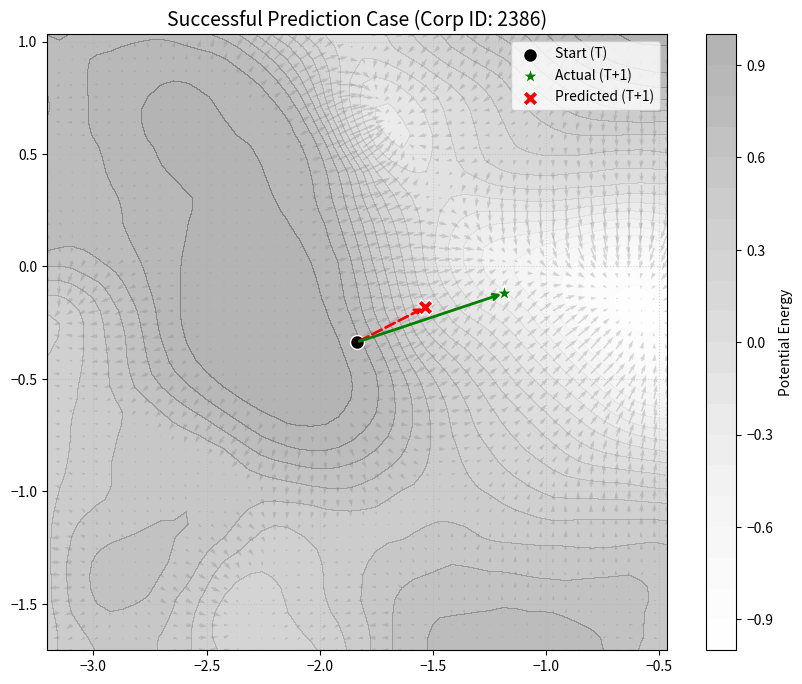

In [41]:
def visualize_successful_case(config, model_proposed, device):
    """
    ProposedモデルがStaticモデル(動かない仮定)よりも上手く予測できた
    「成功事例（企業）」を自動探索し、その軌跡とポテンシャル場を描画する
    """
    print(f"{'='*60}")
    print(" Visualizing a Successful Prediction Case")
    print(f"{'='*60}")
    
    model_proposed.eval()
    
    # データ準備
    years = sorted(config['graphs'].keys())
    target_year = years[-1]       # T+1 (正解)
    input_year = years[-2]        # T   (スタート地点)
    history_years = years[-4:-1]
    
    # エンコード
    z_history = []
    with torch.no_grad():
        for y in history_years:
            d = config['graphs'][y].to(device)
            z, _, _ = model_proposed.encode(d.x, d.edge_index)
            z_history.append(z)
        
        # 未来予測 (Predicted)
        z_pred = model_proposed.predict_future(z_history)
        
        # 正解 (Ground Truth)
        data_target = config['graphs'][target_year].to(device)
        z_true, _, _ = model_proposed.encode(data_target.x, data_target.edge_index)
        
        # 1年前 (Start Point)
        z_start = z_history[-1]

    # ---------------------------------------------------------
    # 成功事例の探索
    # 条件: 「予測位置」が「スタート地点」よりも「正解」に近い企業を探す
    # ---------------------------------------------------------
    mask_corp = torch.arange(model_proposed.num_nodes, device=device) < config['num_corps']
    
    # 企業ごとのベクトル抽出
    idx_map = torch.where(mask_corp)[0] # Global ID -> Array Index
    z_s = z_start[mask_corp]
    z_t = z_true[mask_corp]
    z_p = z_pred[mask_corp]
    
    # 誤差計算
    # Error if we assume static: ||True - Start||
    err_static = torch.norm(z_t - z_s, dim=1)
    # Error of our model: ||True - Pred||
    err_prop = torch.norm(z_t - z_p, dim=1)
    
    # Improvement: (Static誤差 - Proposed誤差) が大きい順
    improvement = err_static - err_prop
    
    # 最も改善した企業のインデックスを取得
    best_idx_local = torch.argmax(improvement).item()
    best_corp_global_id = idx_map[best_idx_local].item()
    
    # 企業名特定
    # all_corporationsリストはpreprocessで作られているはず
    corp_name = "株式会社大林組"
    # config['init_vectors']を作成した際のcorporationリストが必要
    # ここでは簡易的にIDを表示
    
    print(f"Best Case Found: Corp ID {best_corp_global_id}")
    print(f"  Static Error: {err_static[best_idx_local]:.4f}")
    print(f"  Prop   Error: {err_prop[best_idx_local]:.4f}")
    print(f"  Improvement:  {improvement[best_idx_local]:.4f}")
    
    # ---------------------------------------------------------
    # 可視化 (2D Plot)
    # ---------------------------------------------------------
    # 座標取得
    p_start = z_s[best_idx_local].cpu().numpy()
    p_true = z_t[best_idx_local].cpu().numpy()
    p_pred = z_p[best_idx_local].cpu().numpy()
    
    # 背景のポテンシャル場計算 (その企業の周辺)
    center = p_start
    margin = max(np.linalg.norm(p_true - p_start), 0.1) * 2.0
    x_range = (center[0]-margin, center[0]+margin)
    y_range = (center[1]-margin, center[1]+margin)
    
    X, Y, Z = model_proposed.temporal_predictor.potential_net.compute_potential_grid(
        x_range, y_range, resolution=50, device=device
    )
    grad_x, grad_y = model_proposed.temporal_predictor.ode_func.compute_gradient_field(X, Y, device=device)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # ポテンシャル等高線
    contour = ax.contourf(X, Y, Z, levels=20, cmap='Greys', alpha=0.3)
    plt.colorbar(contour, label='Potential Energy')
    
    # ベクトル場
    ax.quiver(X, Y, -grad_x, -grad_y, color='gray', alpha=0.3)
    
    # 軌跡の描画
    # 1. Start (T)
    ax.scatter(p_start[0], p_start[1], c='black', s=100, label='Start (T)', marker='o', edgecolors='white')
    
    # 2. True (T+1)
    ax.scatter(p_true[0], p_true[1], c='green', s=150, label='Actual (T+1)', marker='*', edgecolors='white')
    
    # 3. Pred (T+1)
    ax.scatter(p_pred[0], p_pred[1], c='red', s=120, label='Predicted (T+1)', marker='X', edgecolors='white')
    
    # 矢印: Start -> Pred
    ax.annotate("", xy=p_pred, xytext=p_start, arrowprops=dict(arrowstyle="->", color='red', lw=2, ls='--'))
    
    # 矢印: Start -> True
    ax.annotate("", xy=p_true, xytext=p_start, arrowprops=dict(arrowstyle="->", color='green', lw=2))

    ax.set_title(f"Successful Prediction Case (Corp ID: {best_corp_global_id})", fontsize=14)
    ax.legend()
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.show()

# === 実行 ===
# analysis_resultsを実行した際の 'Proposed' モデルが残っていると仮定
# もし残っていなければ、再学習が必要ですが、基本的には直前のセルの model を使えばOKです
if 'config' in locals():
    # 注意: ここでは直前に学習した Proposed モデルを再利用します。
    # 変数名がループ内で上書きされている場合は、下記のように再学習してください。
    
    print("Re-training Proposed model for visualization...")
    model_vis = UnifiedVGAE(config['total_n'], config['num_corps'], config['in_dim'], 
                            hidden_dim=128, latent_dim=2, 
                            initial_corp_vectors=config['init_vectors'],
                            use_ode=True, use_potential=True).to(device)
    model_vis, _, _ = train_model_improved(
        model_vis, config['graphs'], config['num_corps'], 
        config['hist_edges'], num_epochs=20 # さきほどと同じEpoch数
    )
    
    visualize_successful_case(config, model_vis, device)

In [42]:
# 可視化関数の plt.show() の前に追加
plt.savefig("./outputs/case_study_株式会社大林組.png", dpi=300, bbox_inches='tight')
print("図を保存しました: ./outputs/case_study_株式会社大林組.png")

図を保存しました: ./outputs/case_study_株式会社大林組.png


<Figure size 640x480 with 0 Axes>